In [166]:
import pandas as pd

In [167]:
#Load Dataset
df = pd.read_csv("../dataset/Student_performance_data_.csv")

In [168]:
#Tampilkan 5 data pertama
print("\n ======= HEAD DATA ======= ")
print(df.head())


 ======= HEAD DATA ======= 
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196    

In [169]:
#Statistik deskriptif
print("\n ======= DESCRIBE DATA ======= ")
print(df.describe())


 ======= DESCRIBE DATA ======= 
         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417    

In [170]:
#Cek Missing Value
print("\n ======= MISSING VALUE ======= ")
print(df.isnull().sum())


 ======= MISSING VALUE ======= 
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [171]:
#Cek Duplicate Data
print("\n ========= DUPLICATE DATA ======= ")
print("Jumlah Duplikat Data : ", df.duplicated().sum())


 ========= DUPLICATE DATA ======= 
Jumlah Duplikat Data :  0


In [172]:
print (" === Data Types ====")
print(df.dtypes)

 === Data Types ====
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [173]:
print(" ==== Statistical Summary ==== ")
print(df.describe())

 ==== Statistical Summary ==== 


         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417     0.458971         1.122813   
min

In [174]:
print(" ======= Correlation with GPA ===== ")
print(df.corr(numeric_only=True)["GPA"].sort_values(ascending=False))


 ======= Correlation with GPA ===== 
GPA                  1.000000
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
StudentID           -0.002697
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314
Name: GPA, dtype: float64


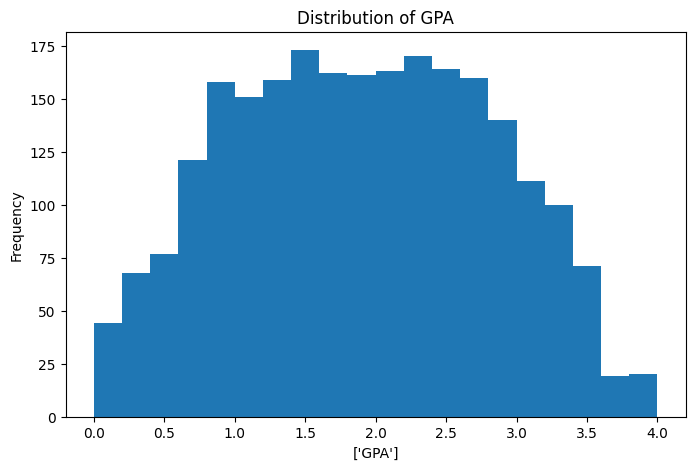

In [175]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["GPA"], bins=20)
plt.title("Distribution of GPA")
plt.xlabel(["GPA"])
plt.ylabel("Frequency")
plt.show()

In [176]:
from sklearn.model_selection import train_test_split

In [177]:
# Drop unnecessary column
df = df.drop(["StudentID", "GradeClass"], axis=1)

In [178]:
# Feature and Target
X = df.drop("GPA", axis=1)
y = df["GPA"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print("X_train shape : ", X_train.shape)
print("X_test shape : ", X_test.shape)
print("y_train shape : ", y_train.shape)
print("y_test shape : ", y_test.shape)

X_train shape :  (1913, 12)
X_test shape :  (479, 12)
y_train shape :  (1913,)
y_test shape :  (479,)


In [179]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model
lr = LinearRegression()

# Training
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Evaluation 
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(" ======== Linear Regresssion Result ======= ")
print(" MAE : ", mae)
print(" MSE : ", mse)
print(" RMSE : ", rmse)
print(" R2 Score : ", r2)

 ======== Linear Regresssion Result ======= 
 MAE :  0.15529483485748097
 MSE :  0.03866144149454257
 RMSE :  0.19662512935670906
 R2 Score :  0.9532471681022928


In [180]:
from sklearn.ensemble import RandomForestRegressor

# Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Training
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print(" ======= Random Forest Regressor ===== ")
print("MAE : ", mae)
print("MSE : ", mse)
print("RMSE : ", rmse)
print("R2 Score : ", r2)


 ======= Random Forest Regressor ===== 
MAE :  0.1908241706555277
MSE :  0.06049515597539183
RMSE :  0.24595763044758712
R2 Score :  0.9268439109198162


In [181]:
from xgboost import XGBRegressor

# Model
xgb = XGBRegressor(
    n_estimators =100,
    learning_rate =0.1,
    max_depth = 5,
    random_state =42
)

# Training
xgb.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(" ====== XGB Result ===== ")
print(" MAE : ", mae)
print(" MSE : ", mse)
print(" RMSE : ", rmse)
print(" R2 Score : ", r2)

 ====== XGB Result ===== 
 MAE :  0.17322149048089477
 MSE :  0.04782358813927529
 RMSE :  0.2186860492561775
 R2 Score :  0.9421674906421599


In [182]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        0.15529483485748097,
        0.1908241706555277,
        0.17322149048089477
    ],
    "RMSE": [
        0.19662512935670906,
        0.24595763044758712,
        0.2186860492561775
    ],
    "R2 Score": [
        0.9532471681022928,
        0.9268439109198162,
        0.9421674906421599
    ]
})

print("===== Model Comparison =====")
print(comparison)

===== Model Comparison =====
               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.155295  0.196625  0.953247
1      Random Forest  0.190824  0.245958  0.926844
2            XGBoost  0.173221  0.218686  0.942167


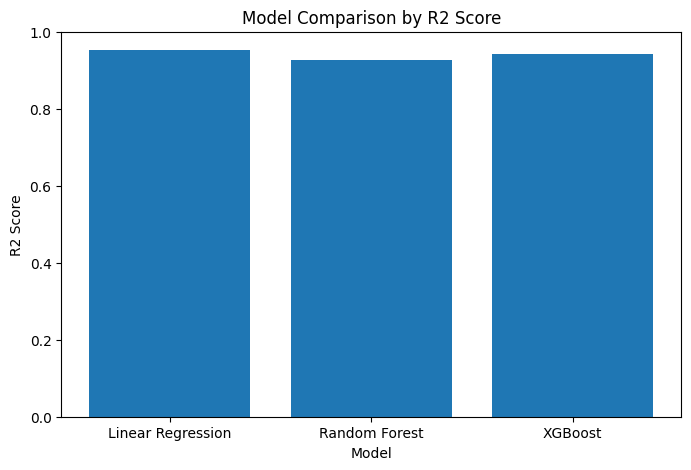

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Model Comparison by R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()

In [184]:
import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(lr, file)
    
print("Best model berhasil disimpan sebagai best_model.pkl")

Best model berhasil disimpan sebagai best_model.pkl
